# Análisis de Encuesta: Intención Emprendedora
**Fuente:** Alba Cabañas M. et al., 2025  
**Pasos:** Carga → Codificación Likert → Alfa de Cronbach → AFE → Regresión múltiple

## 0. Dependencias

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
import pingouin as pg

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga y limpieza de datos

In [2]:
# Cargar archivo CSV
FILE = 'datos_encuesta_2025.csv'

df_raw = pd.read_csv(FILE)
print(f'Dimensiones originales: {df_raw.shape}')
df_raw.head(3)

Dimensiones originales: (540, 131)


,Country,Age,Semester,Exp,Gender,R1,R2,R3,R4,R5,...,EW2,EW3,EW4,EW5,FL1,FL2,FL3,FL4,FL5,FL6
0,3,1,8,2,1,3,4,3,5,2,...,6,5,4,4,2,2,3,3,3,2
1,3,1,8,1,1,5,4,4,3,3,...,5,5,5,5,4,4,4,4,4,4
2,3,1,8,2,3,3,3,3,1,4,...,7,7,7,7,3,4,3,3,3,3


In [3]:
# ── Definición de escalas ──────────────────────────────────────────────────
DEMO_COLS  = ['Country', 'Age', 'Semester', 'Exp', 'Gender']

SCALES = {
    'Resiliencia (R)'           : [f'R{i}' for i in range(1, 10)],
    'Int. Emprendedora (EI)'    : [f'EI{i}' for i in range(1, 6)],
    'Act. Emprendedora (EA)'    : [f'EA{i}' for i in range(1, 9)],
    'Motivación (M)'            : ['M1', 'M2'],
    'Financiamiento (F)'        : ['F1', 'F2'],
    'Género percibido (G)'      : [f'G{i}' for i in range(1, 5)],
    'Soporte social (S)'        : ['S1', 'S2', 'S3'],
    'Uso TIC (U)'               : ['U1', 'U2', 'U3'],
    'Inf. Univ. (UI)'           : ['UI-1'],
    'Desarrollo Univ. (U-D)'    : [f'U-D{i}' for i in range(1, 6)],
    'Apoyo Acad. (U-AS)'        : ['U-AS1', 'U-AS2', 'U-AS3'],
    'Clima Aprend. (LC)'        : [f'LC{i}' for i in range(1, 9)],
    'Act. Emprendedora EAct'    : [f'EAct{i}' for i in range(1, 17)],
    'Conoc. Formal (FK)'        : [f'FK{i}' for i in range(1, 9)],
    'Comp. Aut. Soc. (EC-SA)'   : ['EC-SA1', 'EC-SA2', 'EC-SA3'],
    'Comp. Aut. Reg. (EC-SR)'   : ['EC-SR1', 'EC-SR2', 'EC-SR3', 'EC-SR4'],
    'Comp. Motivación (EC-M)'   : ['EC-M1', 'EC-M2', 'EC-M3', 'EC-M4'],
    'Comp. Empatía (EC-E)'      : ['EC-E1', 'EC-E2', 'EC-E3', 'EC-E4', 'EC-E5'],
    'Comp. H. Sociales (EC-SS)' : ['EC-SS1', 'EC-SS2', 'EC-SS3', 'EC-SS4', 'EC-SS5'],
    'Autoeficacia (SE)'         : [f'SE{i}' for i in range(1, 6)],
    'Liderazgo Creativo (CL)'   : [f'CL{i}' for i in range(1, 13)],
    'Deseo Emprendedor (EW)'    : [f'EW{i}' for i in range(1, 6)],
    'Alfabetización Fin. (FL)'  : [f'FL{i}' for i in range(1, 7)],
}

# Variable dependiente
EI_ITEMS = SCALES['Int. Emprendedora (EI)']

print('Escalas definidas:', len(SCALES))

Escalas definidas: 23


## 2. Codificación de escalas Likert

In [4]:
df = df_raw.copy()

# ── Obtener todos los ítems Likert ─────────────────────────────────────────
all_items = [item for items in SCALES.values() for item in items]

# Convertir a numérico (coerce convierte entradas no numéricas a NaN)
for col in all_items:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Registrar filas con valores faltantes antes de imputar
missing = df[all_items].isnull().sum()
print('Ítems con valores NaN tras conversión:')
print(missing[missing > 0] if missing.any() else '  Ninguno — datos completos.')

# Imputar con la mediana del ítem (estrategia conservadora)
for col in all_items:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# ── Rango de escalas ──────────────────────────────────────────────────────
range_info = {}
for name, items in SCALES.items():
    mn = int(df[items].min().min())
    mx = int(df[items].max().max())
    range_info[name] = (mn, mx)

range_df = pd.DataFrame(range_info, index=['Min', 'Max']).T
print('\nRango observado por escala:')
print(range_df.to_string())

Ítems con valores NaN tras conversión:
R1    1
dtype: int64

Rango observado por escala:
                           Min  Max
Resiliencia (R)              1    5
Int. Emprendedora (EI)       1    5
Act. Emprendedora (EA)       1    5
Motivación (M)               1    5
Financiamiento (F)           1    5
Género percibido (G)         1    5
Soporte social (S)           1    5
Uso TIC (U)                  1    5
Inf. Univ. (UI)              1    5
Desarrollo Univ. (U-D)       1    5
Apoyo Acad. (U-AS)           1    5
Clima Aprend. (LC)           1    5
Act. Emprendedora EAct       1    5
Conoc. Formal (FK)           1    5
Comp. Aut. Soc. (EC-SA)      1    5
Comp. Aut. Reg. (EC-SR)      1    5
Comp. Motivación (EC-M)      1    5
Comp. Empatía (EC-E)         1    5
Comp. H. Sociales (EC-SS)    1    5
Autoeficacia (SE)            1    5
Liderazgo Creativo (CL)      1    5
Deseo Emprendedor (EW)       1    7
Alfabetización Fin. (FL)     1    5


In [5]:
# ── Estandarizar escalas con distinto rango (ej. EW: 1-7) a escala 1-5 ───
# Se usa rescalado lineal: x' = 1 + (x - min)/(max - min) * 4
EW_ITEMS = SCALES['Deseo Emprendedor (EW)']

for col in EW_ITEMS:
    observed_min, observed_max = df[col].min(), df[col].max()
    if observed_max > 5:
        df[col] = 1 + (df[col] - 1) / (7 - 1) * 4   # 1-7 → 1-5

print('Rango EW tras normalización:')
print(df[EW_ITEMS].describe().loc[['min','max']])

Rango EW tras normalización:
     EW1  EW2  EW3  EW4  EW5
min  1.0  1.0  1.0  1.0  1.0
max  5.0  5.0  5.0  5.0  5.0


In [6]:
# ── Crear puntuaciones compuestas (media de ítems por escala) ─────────────
score_cols = {}
for name, items in SCALES.items():
    short = name.split('(')[-1].rstrip(')')
    df[f'SCORE_{short}'] = df[items].mean(axis=1)
    score_cols[name] = f'SCORE_{short}'

score_names = list(score_cols.values())
print('Puntuaciones compuestas creadas:', score_names[:5], '...')
df[score_names].describe().round(3)

Puntuaciones compuestas creadas: ['SCORE_R', 'SCORE_EI', 'SCORE_EA', 'SCORE_M', 'SCORE_F'] ...


,SCORE_R,SCORE_EI,SCORE_EA,SCORE_M,SCORE_F,SCORE_G,SCORE_S,SCORE_U,SCORE_UI,SCORE_U-D,...,SCORE_FK,SCORE_EC-SA,SCORE_EC-SR,SCORE_EC-M,SCORE_EC-E,SCORE_EC-SS,SCORE_SE,SCORE_CL,SCORE_EW,SCORE_FL
count,540.000,540.000,540.000,540.000,540.000,540.000,540.000,540.000,540.000,540.000,...,540.000,540.000,540.000,540.000,540.000,540.000,540.000,540.000,540.000,540.000
mean,3.398,4.021,4.065,2.115,2.688,2.436,3.577,3.479,3.470,3.634,...,3.709,4.070,4.124,4.022,3.993,3.819,3.839,3.282,3.514,2.949
std,0.573,0.977,0.805,0.847,0.653,0.596,0.836,1.029,1.088,0.885,...,0.887,0.863,0.872,0.857,0.829,0.867,0.860,0.446,0.955,0.916
min,1.444,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.167,1.000,1.000
25%,3.000,3.600,3.750,1.500,2.500,2.000,3.000,3.000,3.000,3.200,...,3.250,4.000,4.000,3.750,3.750,3.400,3.400,3.000,3.000,2.333
50%,3.444,4.000,4.125,2.000,3.000,2.250,3.667,3.667,4.000,3.800,...,3.875,4.000,4.000,4.000,4.000,4.000,4.000,3.250,3.667,3.000
75%,3.778,4.800,4.625,2.500,3.000,3.000,4.000,4.000,4.000,4.000,...,4.125,4.750,5.000,4.750,4.600,4.400,4.400,3.583,4.333,3.500
max,5.000,5.000,5.000,5.000,4.500,4.000,5.000,5.000,5.000,5.000,...,5.000,5.000,5.000,5.000,5.000,5.000,5.000,4.500,5.000,5.000


## 3. Estadísticos descriptivos

In [7]:
desc = df[score_names].agg(['mean','median','std','min','max']).T.round(3)
desc.index = [n.replace('SCORE_','') for n in desc.index]
desc.columns = ['Media','Mediana','DE','Mín','Máx']
print('Estadísticos descriptivos de puntuaciones compuestas:')
display(desc)

Estadísticos descriptivos de puntuaciones compuestas:


,Media,Mediana,DE,Mín,Máx
R,3.398,3.444,0.573,1.444,5.000
EI,4.021,4.000,0.977,1.000,5.000
EA,4.065,4.125,0.805,1.000,5.000
M,2.115,2.000,0.847,1.000,5.000
F,2.688,3.000,0.653,1.000,4.500
G,2.436,2.250,0.596,1.000,4.000
S,3.577,3.667,0.836,1.000,5.000
U,3.479,3.667,1.029,1.000,5.000
UI,3.470,4.000,1.088,1.000,5.000
U-D,3.634,3.800,0.885,1.000,5.000


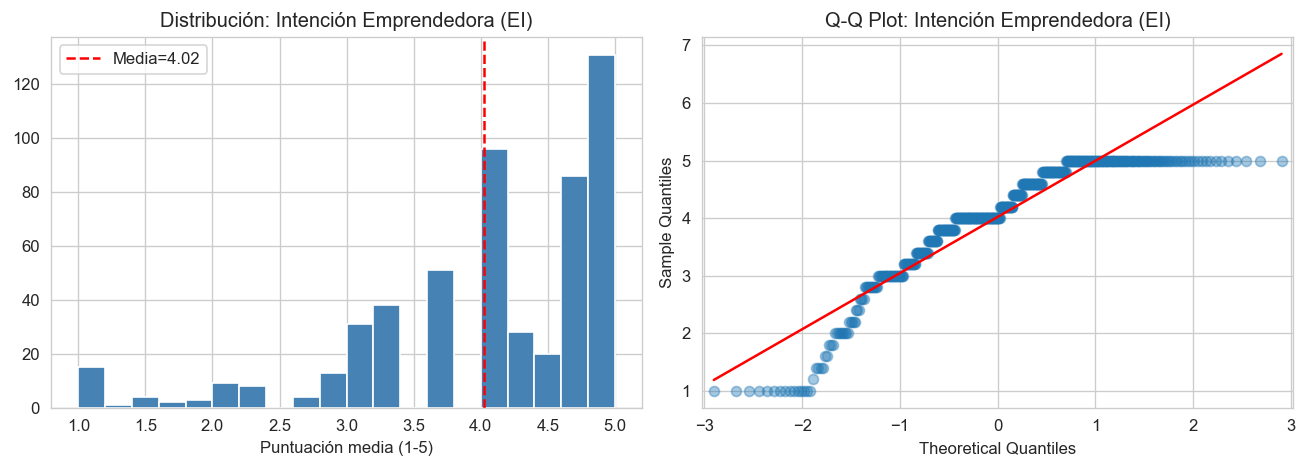

Prueba de Shapiro-Wilk: W=0.8611, p=0.0000


In [8]:
# Distribución de la variable dependiente (EI)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df['SCORE_EI'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(df['SCORE_EI'].mean(), color='red', linestyle='--', label=f'Media={df["SCORE_EI"].mean():.2f}')
axes[0].set_title('Distribución: Intención Emprendedora (EI)')
axes[0].set_xlabel('Puntuación media (1-5)')
axes[0].legend()

sm.qqplot(df['SCORE_EI'], line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Q-Q Plot: Intención Emprendedora (EI)')

plt.tight_layout()
plt.savefig('fig1_distribucion_EI.png', bbox_inches='tight')
plt.show()

stat, p = stats.shapiro(df['SCORE_EI'])
print(f'Prueba de Shapiro-Wilk: W={stat:.4f}, p={p:.4f}')

## 4. Fiabilidad: Alfa de Cronbach

In [9]:
def cronbach_alpha(data: pd.DataFrame) -> float:
    """Calcula el alfa de Cronbach para un conjunto de ítems."""
    k = data.shape[1]
    if k < 2:
        return np.nan
    item_variances = data.var(axis=0, ddof=1).sum()
    total_variance  = data.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_variances / total_variance)


reliability_results = []
for name, items in SCALES.items():
    if len(items) < 2:
        alpha = np.nan
        interpretation = 'N/A (1 ítem)'
    else:
        alpha = cronbach_alpha(df[items])
        if alpha >= 0.9:
            interpretation = 'Excelente'
        elif alpha >= 0.8:
            interpretation = 'Bueno'
        elif alpha >= 0.7:
            interpretation = 'Aceptable'
        elif alpha >= 0.6:
            interpretation = 'Cuestionable'
        else:
            interpretation = 'Pobre'

    reliability_results.append({
        'Escala'        : name,
        'N ítems'       : len(items),
        'Alpha (α)'     : round(alpha, 4) if not np.isnan(alpha) else np.nan,
        'Interpretación': interpretation
    })

alpha_df = pd.DataFrame(reliability_results)
print('Análisis de fiabilidad (Alfa de Cronbach):')
display(alpha_df.style.background_gradient(
    subset=['Alpha (α)'], cmap='RdYlGn', vmin=0.5, vmax=1.0
))

Análisis de fiabilidad (Alfa de Cronbach):


,Escala,N ítems,Alpha (α),Interpretación
0,Resiliencia (R),9,0.600300,Cuestionable
1,Int. Emprendedora (EI),5,0.960100,Excelente
2,Act. Emprendedora (EA),8,0.919700,Excelente
3,Motivación (M),2,0.709200,Aceptable
4,Financiamiento (F),2,-0.555100,Pobre
5,Género percibido (G),4,-0.062200,Pobre
6,Soporte social (S),3,0.761300,Aceptable
7,Uso TIC (U),3,0.928100,Excelente
8,Inf. Univ. (UI),1,nan,N/A (1 ítem)
9,Desarrollo Univ. (U-D),5,0.911800,Excelente


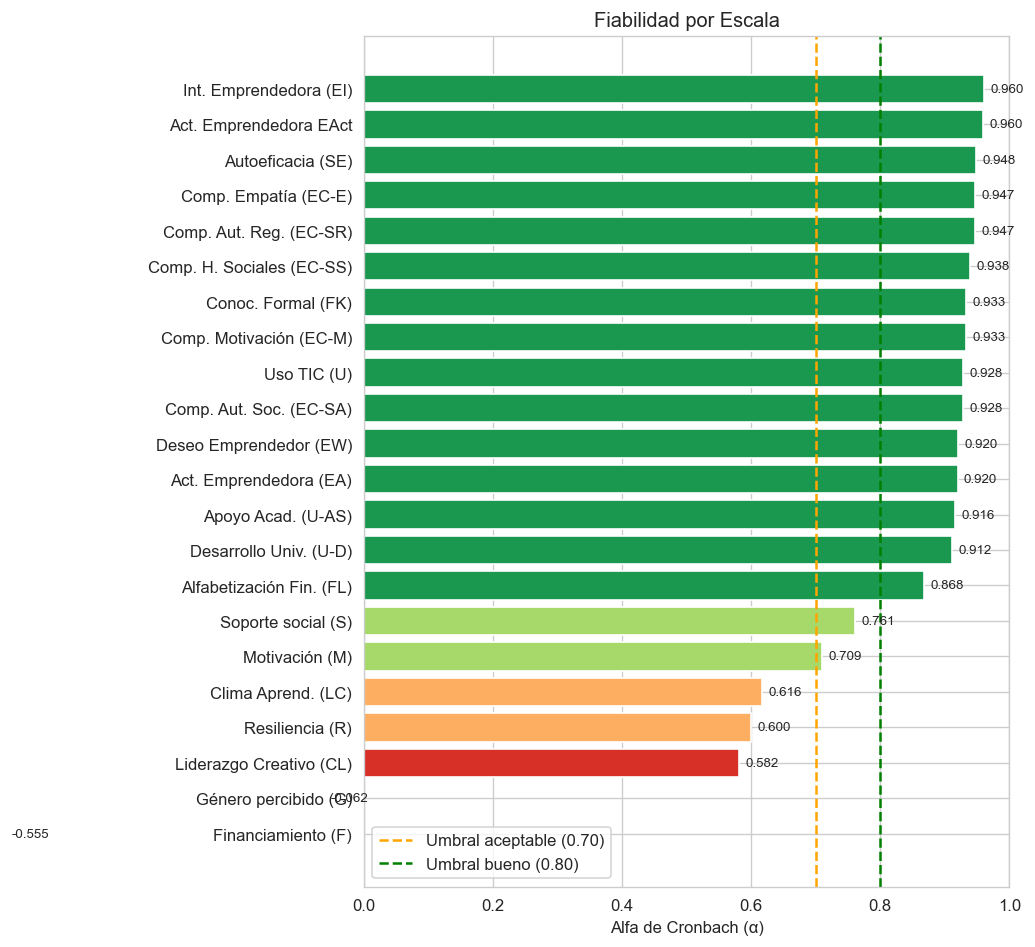

In [10]:
# Visualización del alfa por escala
alpha_plot = alpha_df.dropna(subset=['Alpha (α)']).copy()
alpha_plot = alpha_plot.sort_values('Alpha (α)', ascending=True)

colors = ['#d73027' if a < 0.6 else '#fdae61' if a < 0.7 else '#a6d96a' if a < 0.8 else '#1a9850'
          for a in alpha_plot['Alpha (α)']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(alpha_plot['Escala'], alpha_plot['Alpha (α)'], color=colors)
ax.axvline(0.7, color='orange', linestyle='--', linewidth=1.5, label='Umbral aceptable (0.70)')
ax.axvline(0.8, color='green',  linestyle='--', linewidth=1.5, label='Umbral bueno (0.80)')
ax.set_xlim(0, 1)
ax.set_xlabel('Alfa de Cronbach (α)')
ax.set_title('Fiabilidad por Escala')
ax.legend()

for bar, val in zip(bars, alpha_plot['Alpha (α)']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig2_cronbach.png', bbox_inches='tight')
plt.show()

## 5. Análisis Factorial Exploratorio (AFE)

In [11]:
# ── Selección de ítems para el AFE ────────────────────────────────────────
# Se incluyen las escalas teóricamente relevantes para la intención emprendedora
EFA_SCALES = {
    'EI'   : SCALES['Int. Emprendedora (EI)'],
    'EA'   : SCALES['Act. Emprendedora (EA)'],
    'SE'   : SCALES['Autoeficacia (SE)'],
    'EW'   : SCALES['Deseo Emprendedor (EW)'],
    'LC'   : SCALES['Clima Aprend. (LC)'],
    'FK'   : SCALES['Conoc. Formal (FK)'],
    'CL'   : SCALES['Liderazgo Creativo (CL)'],
    'EC-SA': SCALES['Comp. Aut. Soc. (EC-SA)'],
    'EC-SR': SCALES['Comp. Aut. Reg. (EC-SR)'],
    'EC-M' : SCALES['Comp. Motivación (EC-M)'],
    'EC-E' : SCALES['Comp. Empatía (EC-E)'],
    'EC-SS': SCALES['Comp. H. Sociales (EC-SS)'],
    'FL'   : SCALES['Alfabetización Fin. (FL)'],
    'R'    : SCALES['Resiliencia (R)'],
}

efa_items = [item for items in EFA_SCALES.values() for item in items]
X_efa = df[efa_items].copy()
print(f'Ítems para AFE: {X_efa.shape[1]} ítems, {X_efa.shape[0]} observaciones')

Ítems para AFE: 87 ítems, 540 observaciones


In [12]:
# ── Pruebas de adecuación muestral ────────────────────────────────────────
chi2, p_bartlett = calculate_bartlett_sphericity(X_efa)
kmo_model, kmo_overall = calculate_kmo(X_efa)

print('='*55)
print('Prueba de Bartlett de esfericidad:')
print(f'  Chi-cuadrado = {chi2:.2f},  p = {p_bartlett:.4e}')
print(f'  → {"Adecuado para AFE" if p_bartlett < 0.05 else "NO adecuado para AFE"}')
print()
print('Medida de adecuación muestral KMO:')
print(f'  KMO global = {kmo_overall:.4f}')
if kmo_overall >= 0.90:
    print('  → Adecuación admirable')
elif kmo_overall >= 0.80:
    print('  → Adecuación meritoria')
elif kmo_overall >= 0.70:
    print('  → Adecuación media')
elif kmo_overall >= 0.60:
    print('  → Adecuación mediocre')
else:
    print('  → Adecuación inaceptable')
print('='*55)

Prueba de Bartlett de esfericidad:
  Chi-cuadrado = 42974.59,  p = 0.0000e+00
  → Adecuado para AFE

Medida de adecuación muestral KMO:
  KMO global = 0.9566
  → Adecuación admirable


Factores con eigenvalue > 1 (regla de Kaiser): 16


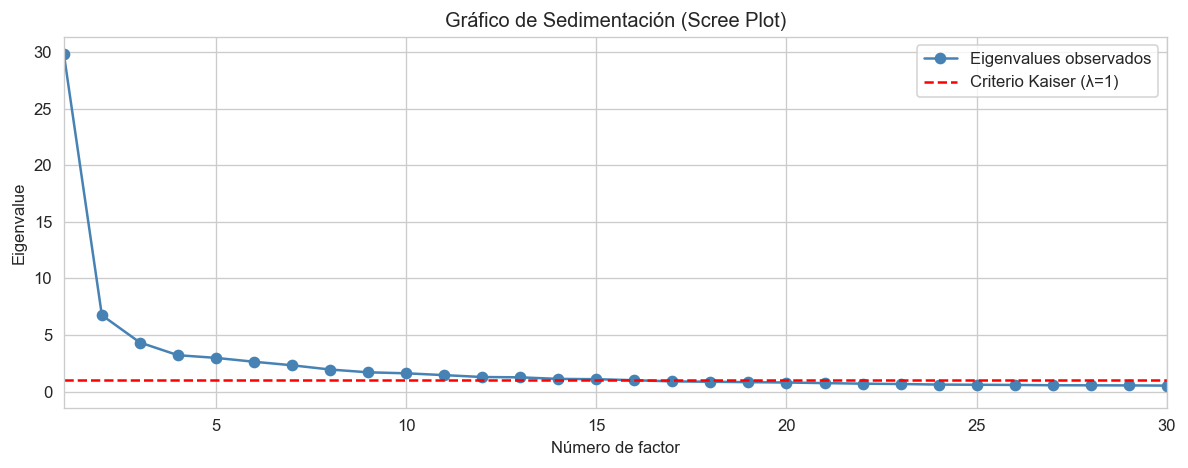

Primeros 15 eigenvalues: [29.838  6.746  4.333  3.212  2.974  2.633  2.321  1.946  1.7    1.612
  1.451  1.283  1.255  1.117  1.093]


In [13]:
# ── Análisis paralelo para determinar número de factores ─────────────────
fa_parallel = FactorAnalyzer(n_factors=1, rotation=None)
fa_parallel.fit(X_efa)
ev, v = fa_parallel.get_eigenvalues()

# Regla de Kaiser: eigenvalues > 1
n_factors_kaiser = int((ev > 1).sum())
print(f'Factores con eigenvalue > 1 (regla de Kaiser): {n_factors_kaiser}')

# Gráfico de sedimentación
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(ev)+1), ev, 'o-', color='steelblue', label='Eigenvalues observados')
ax.axhline(1, color='red', linestyle='--', label='Criterio Kaiser (λ=1)')
ax.set_xlabel('Número de factor')
ax.set_ylabel('Eigenvalue')
ax.set_title('Gráfico de Sedimentación (Scree Plot)')
ax.set_xlim(1, min(30, len(ev)))
ax.legend()
plt.tight_layout()
plt.savefig('fig3_scree_plot.png', bbox_inches='tight')
plt.show()
print(f'Primeros 15 eigenvalues: {np.round(ev[:15], 3)}')

In [14]:
# ── AFE con rotación Oblimin (permite correlación entre factores) ─────────
N_FACTORS = min(n_factors_kaiser, 14)  # Cap para evitar sobreextracción
print(f'Extrayendo {N_FACTORS} factores con rotación Oblimin...')

fa = FactorAnalyzer(n_factors=N_FACTORS, rotation='oblimin', method='ml')
fa.fit(X_efa)

# Cargas factoriales
loadings = pd.DataFrame(
    fa.loadings_,
    index=efa_items,
    columns=[f'F{i+1}' for i in range(N_FACTORS)]
)

# Varianza explicada
variance_df = pd.DataFrame(
    fa.get_factor_variance(),
    index=['SS Cargas', '% Varianza', '% Varianza Acum.'],
    columns=[f'F{i+1}' for i in range(N_FACTORS)]
).round(4)

print('\nVarianza explicada por factor:')
display(variance_df)

Extrayendo 14 factores con rotación Oblimin...



Varianza explicada por factor:


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14
SS Cargas,5.1705,4.5119,4.4240,3.6334,3.4155,3.2499,3.0024,2.9850,2.8459,2.8337,2.4164,2.0877,2.0397,2.0284
% Varianza,0.0594,0.0519,0.0509,0.0418,0.0393,0.0374,0.0345,0.0343,0.0327,0.0326,0.0278,0.0240,0.0234,0.0233
% Varianza Acum.,0.0594,0.1113,0.1621,0.2039,0.2432,0.2805,0.3150,0.3493,0.3821,0.4146,0.4424,0.4664,0.4898,0.5132


In [15]:
# ── Tabla de cargas (sólo cargas |λ| > 0.30) ─────────────────────────────
loadings_display = loadings.copy()
loadings_display = loadings_display.applymap(lambda x: round(x, 3) if abs(x) >= 0.30 else '')

print('Cargas factoriales (|λ| ≥ 0.30):')
display(loadings_display)

Cargas factoriales (|λ| ≥ 0.30):


,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14
EI1,,,0.825,,,,,,,,,,,
EI2,,,0.861,,,,,,,,,,,
EI3,,,0.914,,,,,,,,,,,
EI4,,,0.931,,,,,,,,,,,
EI5,,,0.914,,,,,,,,,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
R5,,,,,,,,,,,,0.44,,
R6,,,,,,,,,,,,0.434,,
R7,,,,,,,,,,,,0.684,,
R8,,,,,,,,,,,,0.694,,


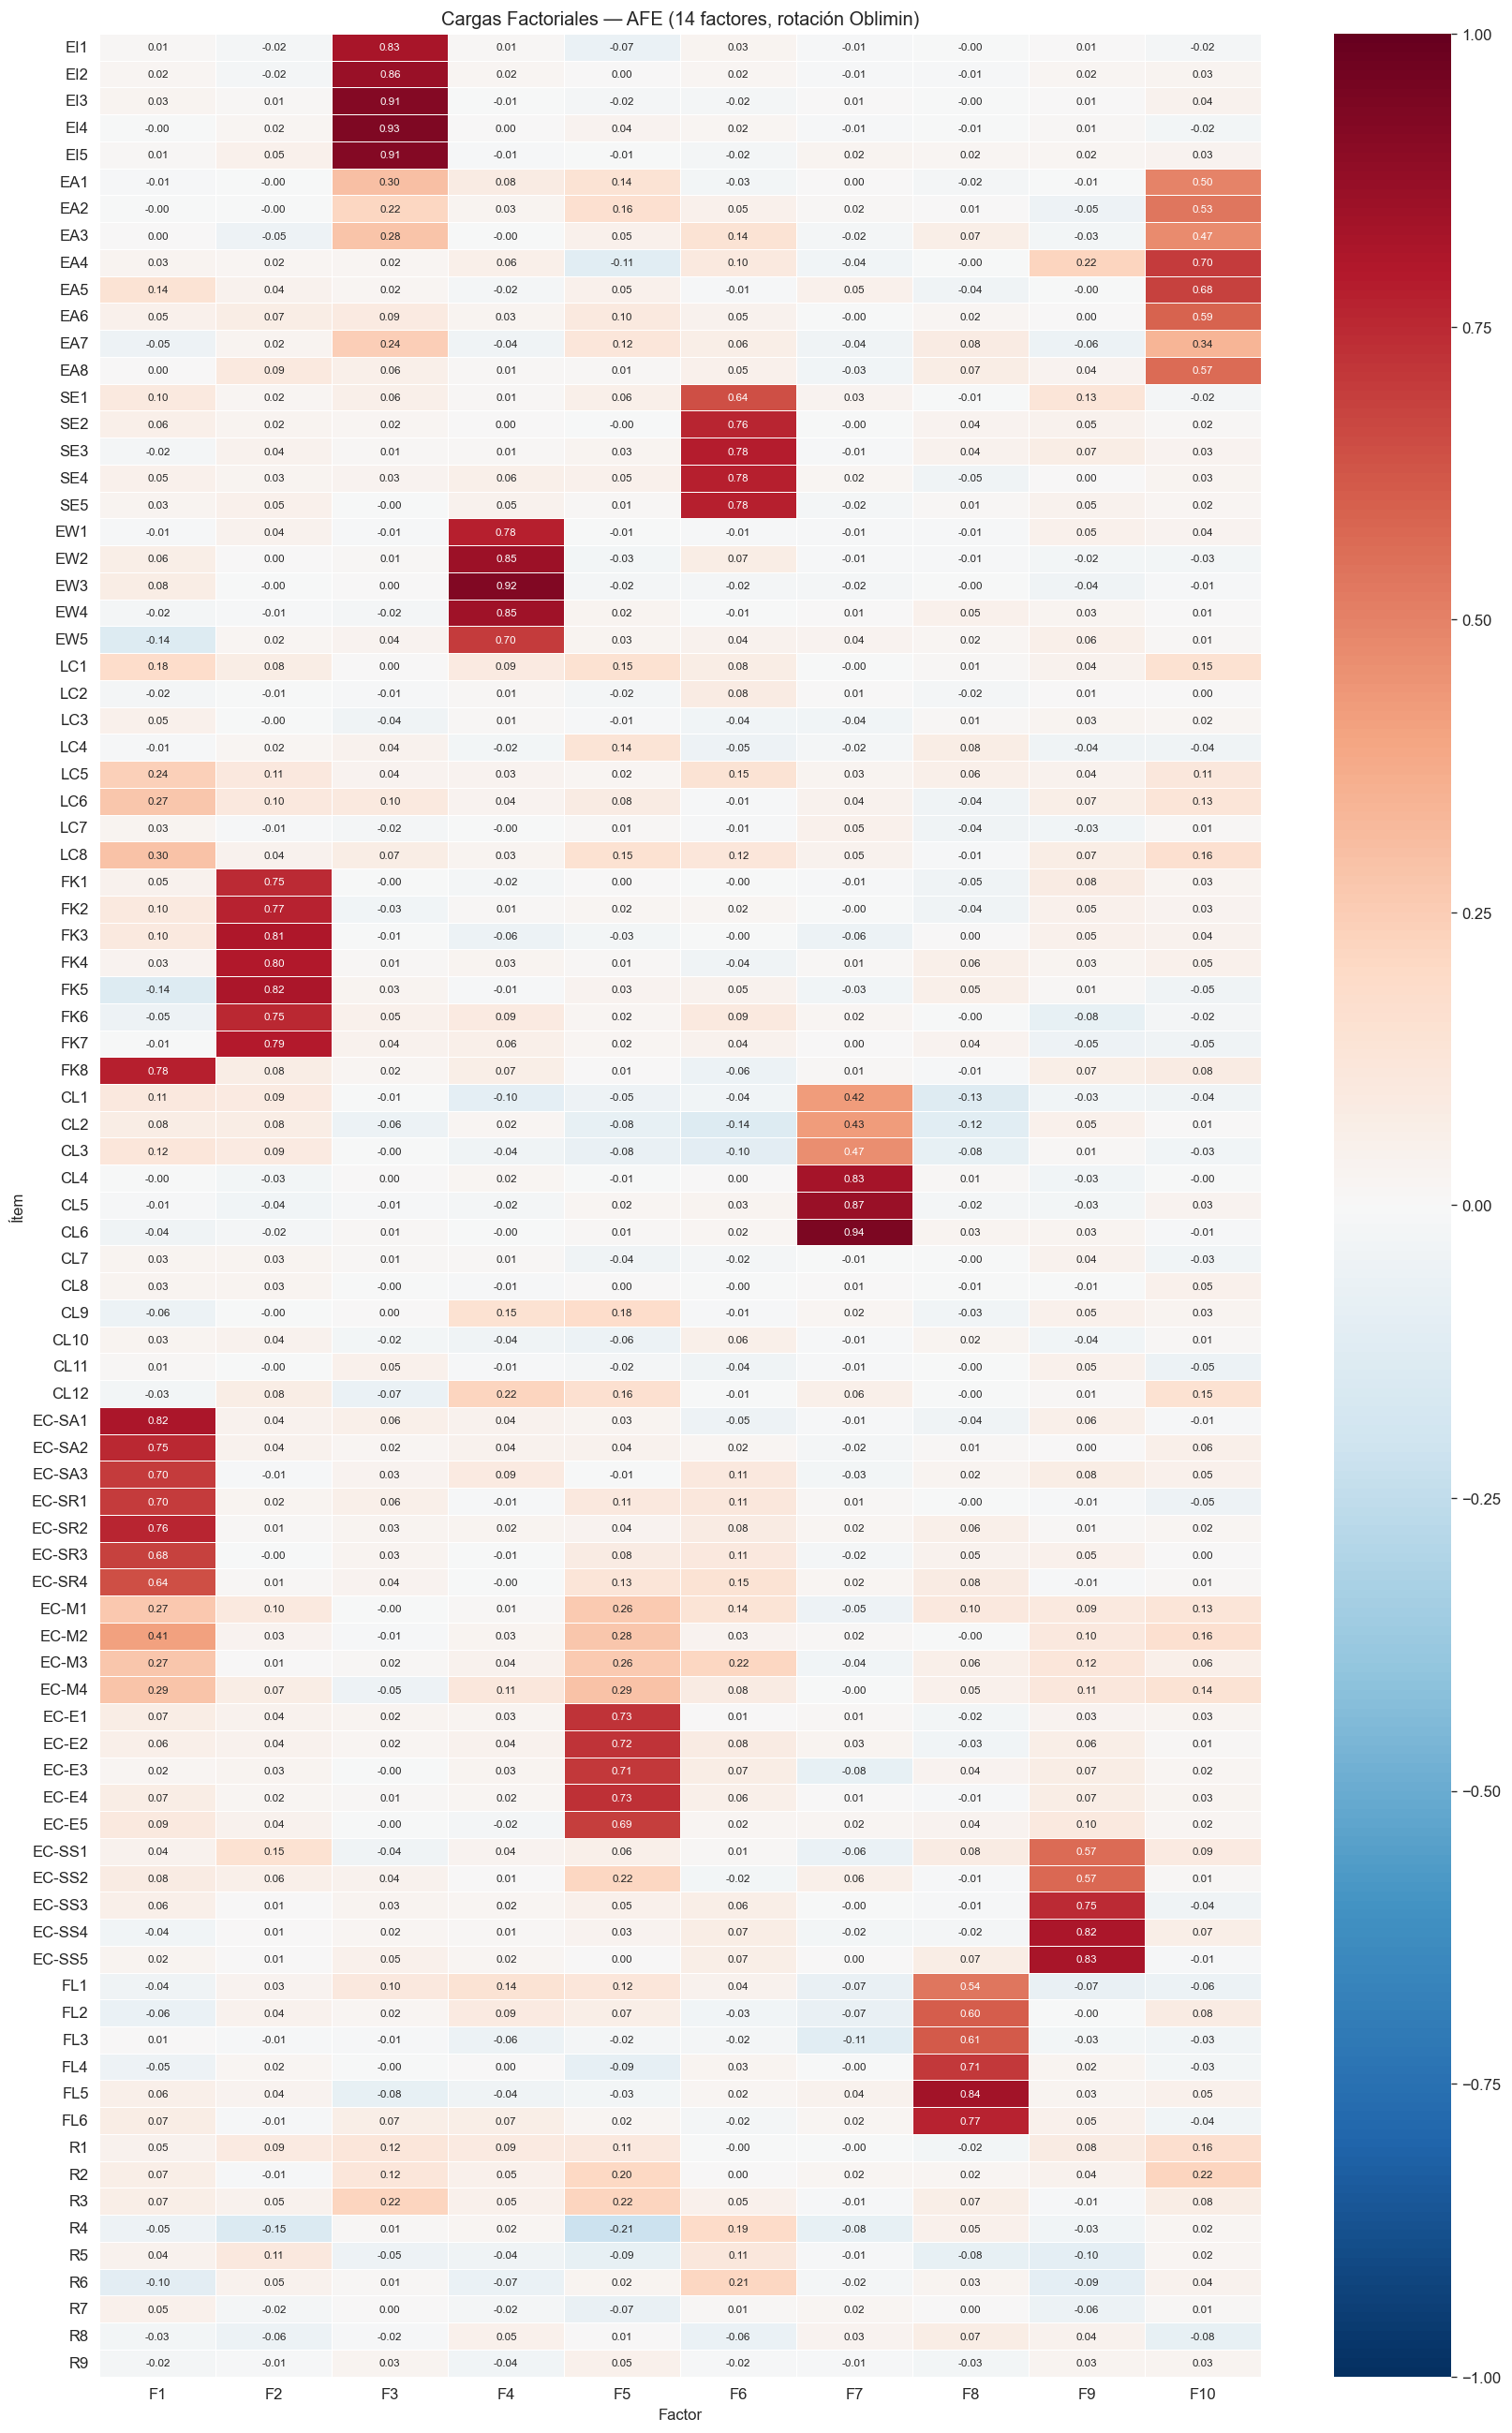

In [16]:
# ── Heatmap de cargas factoriales ─────────────────────────────────────────
n_show_factors = min(10, N_FACTORS)  # Mostrar hasta 10 factores
loadings_abs = loadings.iloc[:, :n_show_factors].abs()

fig, ax = plt.subplots(figsize=(14, max(8, len(efa_items) * 0.25)))
sns.heatmap(
    loadings.iloc[:, :n_show_factors],
    annot=True, fmt='.2f', cmap='RdBu_r',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5, annot_kws={'size': 7},
    ax=ax
)
ax.set_title(f'Cargas Factoriales — AFE ({N_FACTORS} factores, rotación Oblimin)')
ax.set_xlabel('Factor')
ax.set_ylabel('Ítem')
plt.tight_layout()
plt.savefig('fig4_cargas_factoriales.png', bbox_inches='tight')
plt.show()

## 6. Regresión Múltiple sobre Intención Emprendedora (EI)

In [17]:
# ── Variable dependiente e independientes ─────────────────────────────────
y = df['SCORE_EI']

# Predictores: puntuaciones compuestas de todas las escalas excepto EI
predictor_cols = [
    score_cols['Resiliencia (R)'],
    score_cols['Act. Emprendedora (EA)'],
    score_cols['Motivación (M)'],
    score_cols['Financiamiento (F)'],
    score_cols['Género percibido (G)'],
    score_cols['Soporte social (S)'],
    score_cols['Clima Aprend. (LC)'],
    score_cols['Conoc. Formal (FK)'],
    score_cols['Autoeficacia (SE)'],
    score_cols['Liderazgo Creativo (CL)'],
    score_cols['Deseo Emprendedor (EW)'],
    score_cols['Alfabetización Fin. (FL)'],
    score_cols['Comp. Aut. Soc. (EC-SA)'],
    score_cols['Comp. Aut. Reg. (EC-SR)'],
    score_cols['Comp. Motivación (EC-M)'],
    score_cols['Comp. Empatía (EC-E)'],
    score_cols['Comp. H. Sociales (EC-SS)'],
]

X = df[predictor_cols]
print(f'Predictores: {len(predictor_cols)}, Observaciones: {len(y)}')

Predictores: 17, Observaciones: 540


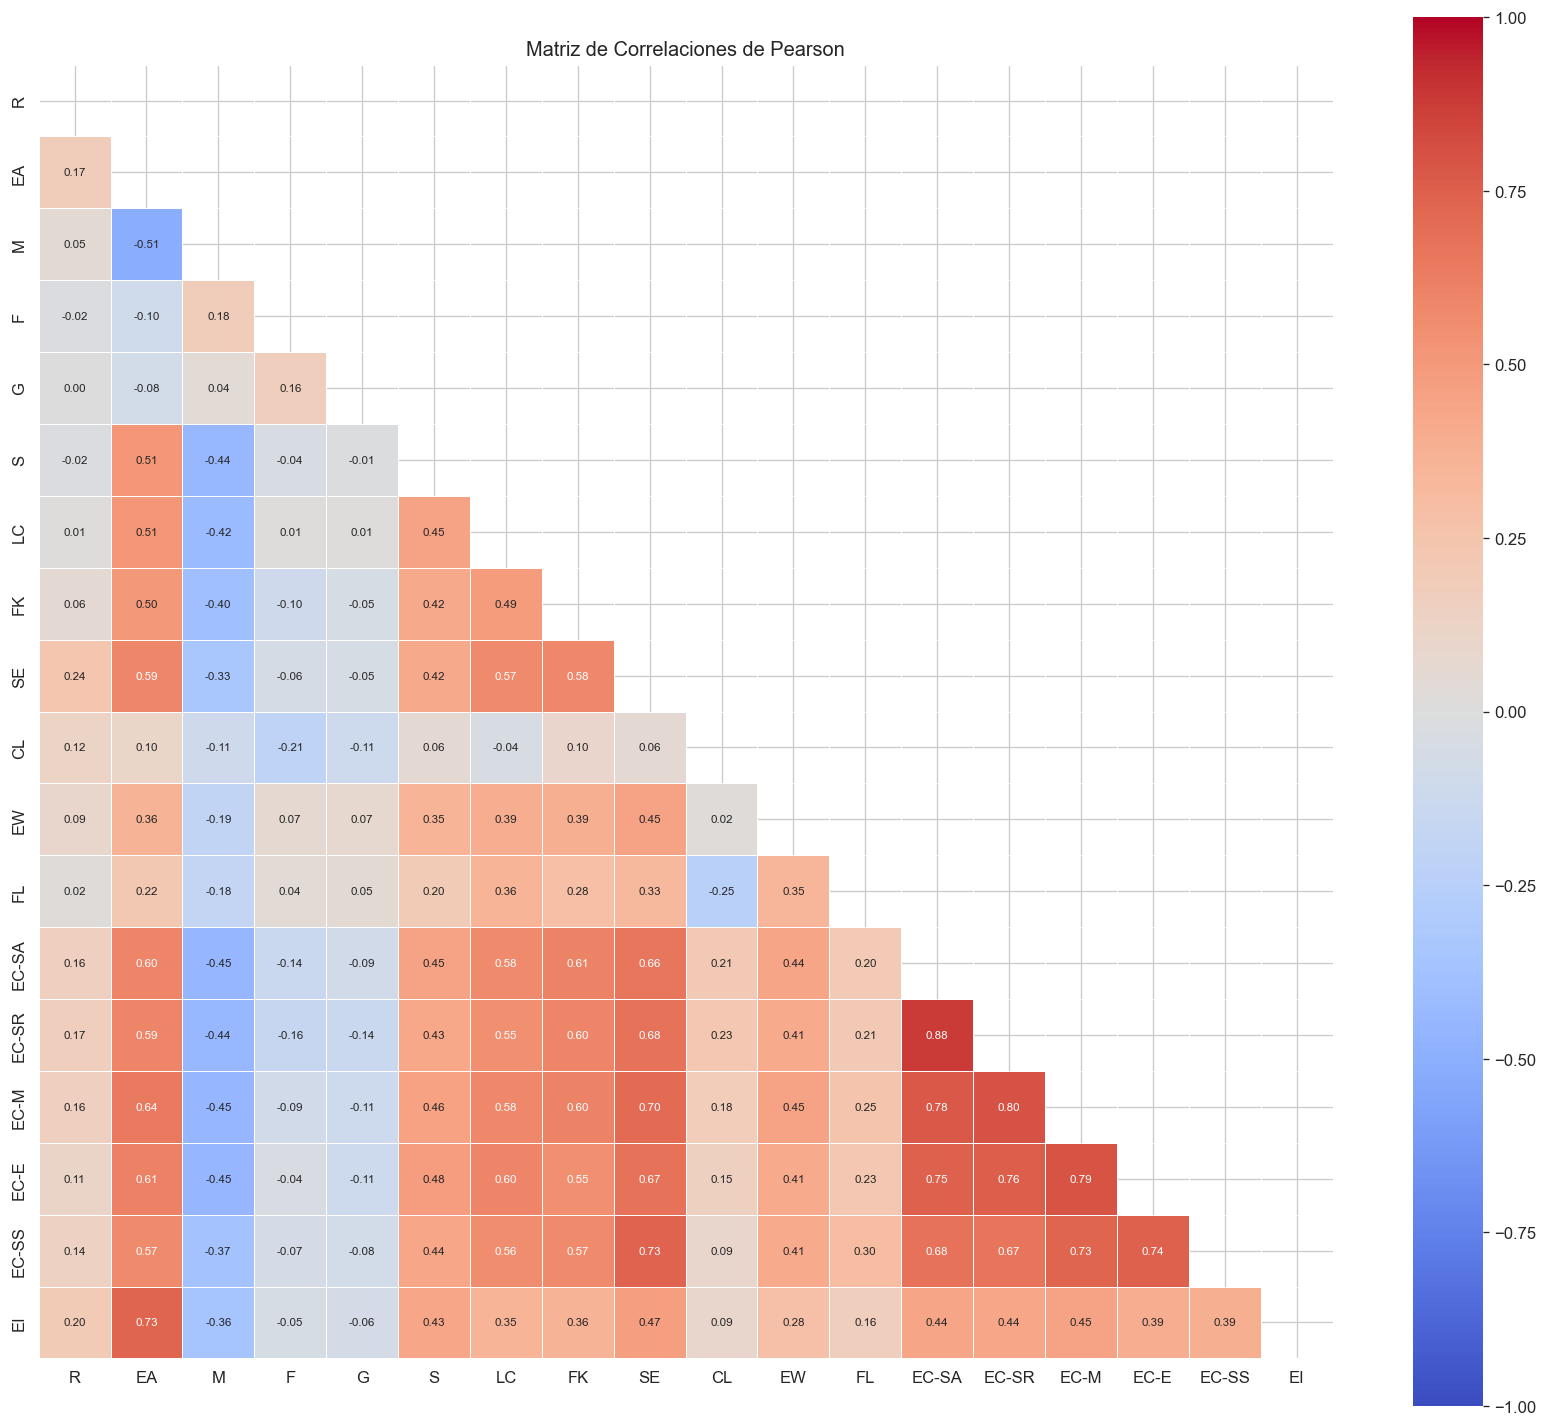

In [18]:
# ── Matriz de correlaciones (predictores + EI) ────────────────────────────
corr_cols = predictor_cols + ['SCORE_EI']
corr_labels = [c.replace('SCORE_','') for c in corr_cols]

corr_matrix = df[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Matriz de Correlaciones de Pearson')
plt.tight_layout()
plt.savefig('fig5_correlaciones.png', bbox_inches='tight')
plt.show()

In [19]:
# ── Regresión con statsmodels (OLS completo) ──────────────────────────────
X_sm = sm.add_constant(X)
modelo = sm.OLS(y, X_sm).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               SCORE_EI   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                     39.26
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           6.53e-82
Time:                        15:42:10   Log-Likelihood:                -530.84
No. Observations:                 540   AIC:                             1098.
Df Residuals:                     522   BIC:                             1175.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0921      0.432     -0.213      

In [20]:
# ── Tabla resumen de coeficientes ─────────────────────────────────────────
coef_df = pd.DataFrame({
    'Predictor'   : [c.replace('SCORE_','') for c in predictor_cols],
    'β'           : modelo.params[1:].values,
    'SE'          : modelo.bse[1:].values,
    't'           : modelo.tvalues[1:].values,
    'p'           : modelo.pvalues[1:].values,
    'Sig.'        : ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '.' if p < 0.1 else ''
                     for p in modelo.pvalues[1:]],
    'IC 95% inf'  : modelo.conf_int().iloc[1:, 0].values,
    'IC 95% sup'  : modelo.conf_int().iloc[1:, 1].values,
}).round(4)

coef_df = coef_df.sort_values('p')
print(f'\nR² = {modelo.rsquared:.4f}   R² ajustado = {modelo.rsquared_adj:.4f}')
print(f'F({modelo.df_model:.0f}, {modelo.df_resid:.0f}) = {modelo.fvalue:.2f},  p = {modelo.f_pvalue:.4e}')
print()
display(coef_df.style.apply(
    lambda row: ['background-color: #d4f1c4' if row['p'] < 0.05 else '' for _ in row], axis=1
))


R² = 0.5611   R² ajustado = 0.5468
F(17, 522) = 39.26,  p = 6.5331e-82



,Predictor,β,SE,t,p,Sig.,IC 95% inf,IC 95% sup
1,EA,0.856900,0.052600,16.300600,0.000000,***,0.753600,0.960200
5,S,0.137800,0.042900,3.210400,0.001400,**,0.053500,0.222100
15,EC-E,-0.188200,0.066300,-2.837900,0.004700,**,-0.318400,-0.057900
8,SE,0.148300,0.057300,2.587200,0.009900,**,0.035700,0.260900
0,R,0.118700,0.053200,2.233000,0.026000,*,0.014300,0.223200
16,EC-SS,-0.071100,0.057600,-1.233100,0.218100,,-0.184300,0.042200
3,F,0.050900,0.046600,1.093400,0.274700,,-0.040600,0.142400
6,LC,-0.055200,0.074700,-0.739300,0.460100,,-0.201900,0.091500
13,EC-SR,0.051000,0.076400,0.667600,0.504700,,-0.099100,0.201100
12,EC-SA,0.044100,0.074100,0.595000,0.552100,,-0.101500,0.189700


In [21]:
# ── Coeficientes estandarizados (β*) ──────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_std = scaler.fit_transform(X)
y_std = scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

X_std_sm = sm.add_constant(X_std)
modelo_std = sm.OLS(y_std, X_std_sm).fit()

beta_std = pd.DataFrame({
    'Predictor'      : [c.replace('SCORE_','') for c in predictor_cols],
    'β estand.'      : modelo_std.params[1:].round(4),
    'p'              : modelo_std.pvalues[1:].round(4),
    'Sig.'           : ['***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
                        for p in modelo_std.pvalues[1:]]
}).sort_values('β estand.', key=abs, ascending=False)

print('Coeficientes estandarizados (importancia relativa):')
display(beta_std)

Coeficientes estandarizados (importancia relativa):


,Predictor,β estand.,p,Sig.
1,EA,0.7062,0.0000,***
15,EC-E,-0.1596,0.0047,**
8,SE,0.1305,0.0099,**
5,S,0.1179,0.0014,**
0,R,0.0696,0.0260,*
16,EC-SS,-0.0631,0.2181,
13,EC-SR,0.0455,0.5047,
12,EC-SA,0.0390,0.5521,
3,F,0.0340,0.2747,
14,EC-M,-0.0311,0.6040,


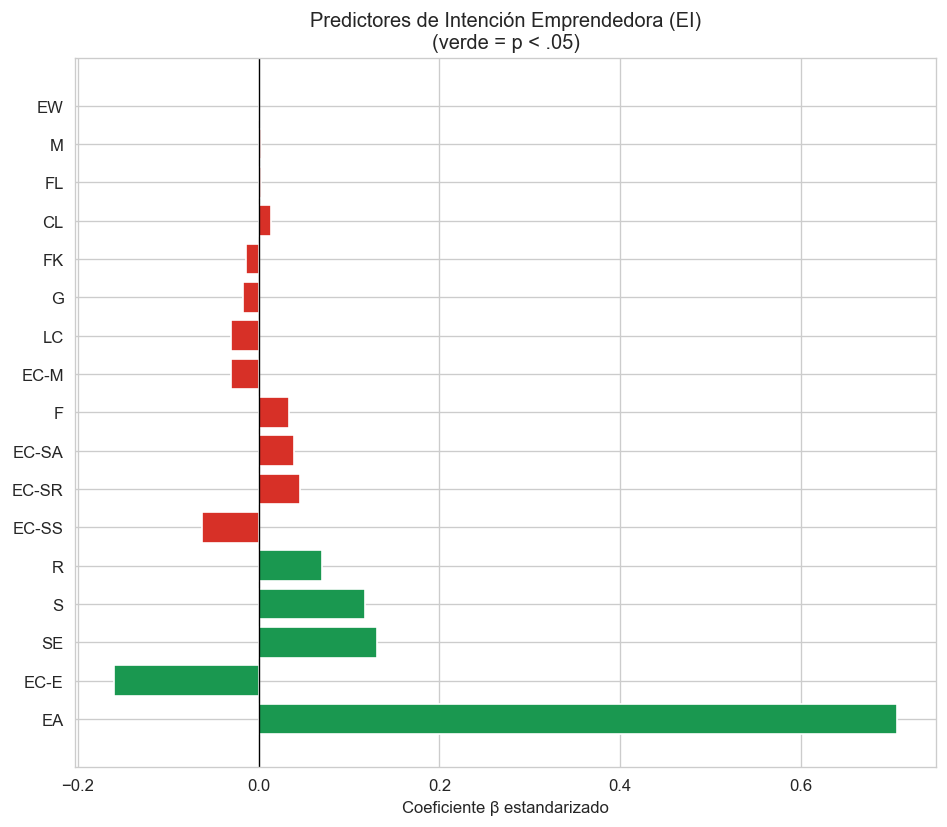

In [22]:
# ── Gráfico de coeficientes estandarizados ────────────────────────────────
sig_mask = beta_std['p'] < 0.05
colors_coef = ['#1a9850' if s else '#d73027' for s in sig_mask]

fig, ax = plt.subplots(figsize=(8, 7))
y_pos = range(len(beta_std))
ax.barh(y_pos, beta_std['β estand.'], color=colors_coef, edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(beta_std['Predictor'])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente β estandarizado')
ax.set_title('Predictores de Intención Emprendedora (EI)\n(verde = p < .05)')
plt.tight_layout()
plt.savefig('fig6_coeficientes.png', bbox_inches='tight')
plt.show()

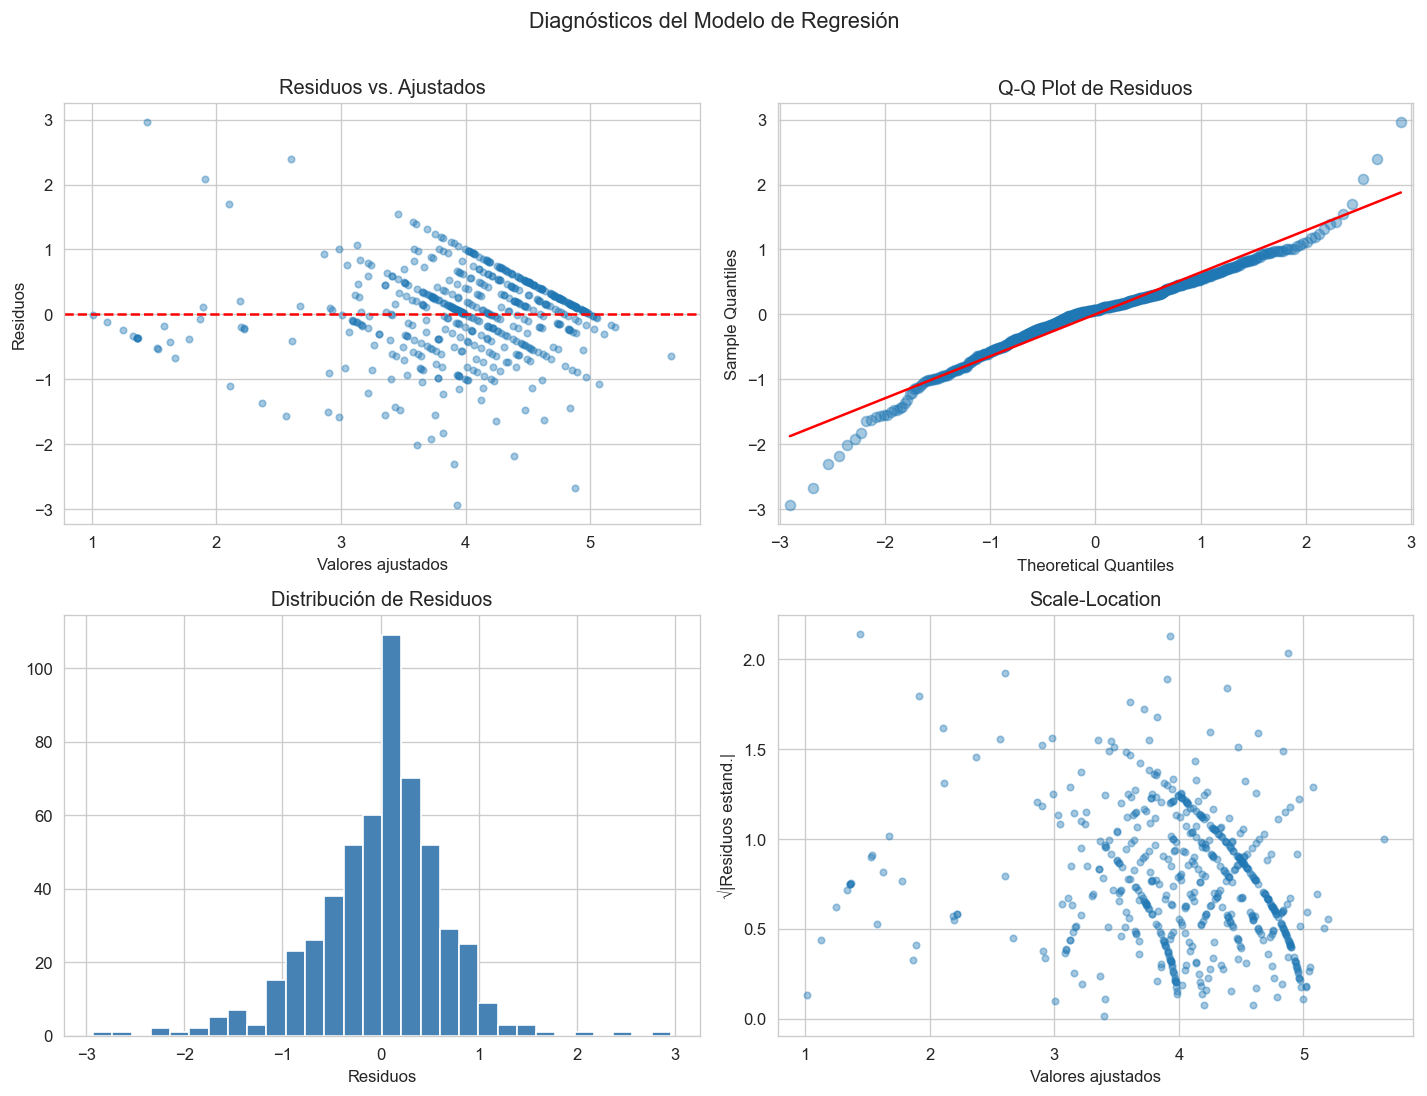

Shapiro-Wilk residuos: W=0.9616, p=0.0000
Breusch-Pagan: LM=33.8403, p=0.0088

Factor de Inflación de Varianza (VIF):
(VIF > 10 indica multicolinealidad severa)


,Predictor,VIF
13,EC-SR,5.532
12,EC-SA,5.096
14,EC-M,4.274
15,EC-E,3.763
16,EC-SS,3.114
8,SE,3.025
1,EA,2.232
6,LC,2.035
7,FK,1.919
2,M,1.625


In [23]:
# ── Diagnósticos del modelo ───────────────────────────────────────────────
residuals   = modelo.resid
fitted      = modelo.fittedvalues
std_resid   = residuals / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Residuos vs valores ajustados
axes[0,0].scatter(fitted, residuals, alpha=0.4, s=15)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel('Valores ajustados')
axes[0,0].set_ylabel('Residuos')
axes[0,0].set_title('Residuos vs. Ajustados')

# 2. Q-Q de residuos
sm.qqplot(residuals, line='s', ax=axes[0,1], alpha=0.4)
axes[0,1].set_title('Q-Q Plot de Residuos')

# 3. Histograma de residuos
axes[1,0].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1,0].set_xlabel('Residuos')
axes[1,0].set_title('Distribución de Residuos')

# 4. Scale-Location
axes[1,1].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.4, s=15)
axes[1,1].set_xlabel('Valores ajustados')
axes[1,1].set_ylabel('√|Residuos estand.|')
axes[1,1].set_title('Scale-Location')

plt.suptitle('Diagnósticos del Modelo de Regresión', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig7_diagnosticos.png', bbox_inches='tight')
plt.show()

# Prueba de normalidad de residuos
stat_r, p_r = stats.shapiro(residuals[:5000])  # Shapiro limitado a 5000
print(f'Shapiro-Wilk residuos: W={stat_r:.4f}, p={p_r:.4f}')

# Prueba de homocedasticidad (Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_stat, bp_p, f_stat, f_p = het_breuschpagan(residuals, modelo.model.exog)
print(f'Breusch-Pagan: LM={bp_stat:.4f}, p={bp_p:.4f}')

# Factor de inflación de varianza (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data['Predictor'] = [c.replace('SCORE_','') for c in predictor_cols]
vif_data['VIF'] = [variance_inflation_factor(X_sm.values, i+1) for i in range(len(predictor_cols))]
vif_data = vif_data.sort_values('VIF', ascending=False).round(3)
print('\nFactor de Inflación de Varianza (VIF):')
print('(VIF > 10 indica multicolinealidad severa)')
display(vif_data)

## 7. Resumen de resultados

In [24]:
sig_predictors = coef_df[coef_df['p'] < 0.05].sort_values('p')

print('=' * 60)
print('RESUMEN EJECUTIVO')
print('=' * 60)
print(f'\nMuestra: N = {len(df)}')
print(f'\n--- Fiabilidad ---')
good = alpha_df[alpha_df['Alpha (α)'] >= 0.70]
print(f'  Escalas con α ≥ 0.70: {len(good)}/{len(alpha_df.dropna())}')
print(f'\n--- AFE ---')
print(f'  KMO = {kmo_overall:.3f}')
print(f'  Factores extraídos: {N_FACTORS}')
var_acum = variance_df.loc['% Varianza Acum.', f'F{N_FACTORS}'] * 100
print(f'  Varianza explicada acumulada: {var_acum:.1f}%')
print(f'\n--- Regresión sobre EI ---')
print(f'  R²           = {modelo.rsquared:.4f}')
print(f'  R² ajustado  = {modelo.rsquared_adj:.4f}')
print(f'  F({modelo.df_model:.0f}, {modelo.df_resid:.0f}) = {modelo.fvalue:.2f},  p = {modelo.f_pvalue:.2e}')
print(f'\nPredictores significativos (p < .05):')
for _, row in sig_predictors.iterrows():
    print(f'  {row["Predictor"]:25s}  β={row["β"]:+.4f}  {row["Sig."]}')
print('=' * 60)

RESUMEN EJECUTIVO

Muestra: N = 540

--- Fiabilidad ---
  Escalas con α ≥ 0.70: 17/22

--- AFE ---
  KMO = 0.957
  Factores extraídos: 14
  Varianza explicada acumulada: 51.3%

--- Regresión sobre EI ---
  R²           = 0.5611
  R² ajustado  = 0.5468
  F(17, 522) = 39.26,  p = 6.53e-82

Predictores significativos (p < .05):
  EA                         β=+0.8569  ***
  S                          β=+0.1378  **
  EC-E                       β=-0.1882  **
  SE                         β=+0.1483  **
  R                          β=+0.1187  *
